# Retail Sales
## Segmentación de Clientes Retail con Análisis
**Pregunta de negocio:** "¿Cómo segmentar el portafolio de clientes mediante RFM para optimizar la estrategia de marketing y maximizar el valor de vida del cliente?" 

**Autor:** José María Urquidi Mimenza  
**Dataset:** Kaggle — Retail Sales Dataset


## 1. Analisis exploratorio y Limpieza

### 1.1 Cargar datos

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el dataset
raw_path = '../data/raw/retail_sales_dataset.csv'
df_raw = pd.read_csv(raw_path)

In [3]:
# Mostrar las primeras filas del dataset
df_raw.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


### 1.2 Análisis EDA

In [4]:
#Analizar la tamaño del dataset
df_raw.shape

(4310, 21)

In [5]:
#Analizar estructura del dataset
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   object 
 1   order_date             4280 non-null   object 
 2   customer_id            4280 non-null   object 
 3   customer_name          4280 non-null   object 
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   object 
 6   region                 4280 non-null   object 
 7   city                   4280 non-null   object 
 8   product_category       4280 non-null   object 
 9   product_name           4280 non-null   object 
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  ship

#### Observaciones

**Problema 1:** El dtype en 'order_date' es string
**Solución:** Modificar a datetime para analisis temporales de ventas.

**Problema 2:** 'return_flaf' es una columna de True/False
**Recomendación:** Convertir a boolean para analísis, ejemplo: correlaciones

**Problema 3:** Varias columnas presentan la misma cantidad de valores nulos
**Procedimiento:** Analizar relevancia y logica de negocio para toma de desición en tratamiento de nulos



### 1.3 Estandarizar dataset

In [6]:
#Agrupar columnas por tipo de dato
#"order_id" y "customer_id" son identificadores únicos, por lo que no se incluyen en ninguna lista
#"customer_name" no se incluye en ninguna lista ya que es un dato de texto libre y no se utilizará para análisis
str_cols=[
             'gender', 
             'region', 
             'city', 
             'product_category',
             'product_name',
             'payment_method', 
             'order_status'
             ]
num_cols=['age',
          'quantity', 
          'unit_price', 
          'discount_pct', 
          'sales_amount', 
          'profit',
          'shipping_cost',
          'customer_satisfaction',
          'days_to_ship'
          ]

bol_cols=['return_flag']

date_cols=['order_date']

In [7]:
#Estandarizar y corregir dtype para "order_date"
#Revisar nulos de datetime
dt_null=df_raw["order_date"].isnull().sum()
print(f"Cantidad de nulos en la columna 'order_date': {dt_null}")


Cantidad de nulos en la columna 'order_date': 30


In [8]:
#Revisar formatos de "order_date"
fechas=df_raw["order_date"].unique()
print(fechas)

['2024-08-15' '2022-08-16' '2021-08-29' ... '2020-12-16' '16/09/2023'
 '2022-02-11']


In [9]:
#Modificar el tipo de dato de la columna "order_date" a datetime
df_raw["order_date"] = pd.to_datetime(
    df_raw["order_date"],
    format="mixed", #Existen formatos YYYY-MM-DD y DD/MM/YYYY
    dayfirst=True,
    errors="coerce"
)
df_raw["order_date"].dtype

dtype('<M8[ns]')

In [10]:
#Revisar si hay nuevos nulos después de la conversión
dt_null_after=df_raw["order_date"].isnull().sum()
print(f"Cantidad de nulos en la columna 'order_date' despues de conversión: {dt_null_after}")
print()
if dt_null == dt_null_after:
    print("No se generaron nulos adicionales después de la conversión.")    
else:
    print("Se generaron nulos adicionales después de la conversión.")

Cantidad de nulos en la columna 'order_date' despues de conversión: 30

No se generaron nulos adicionales después de la conversión.


In [11]:
#Revisar fechas únicas después de la conversión
df_raw["order_date"].unique()

<DatetimeArray>
['2024-08-15 00:00:00', '2022-08-16 00:00:00', '2021-08-29 00:00:00',
 '2022-07-05 00:00:00', '2020-05-07 00:00:00', '2024-09-02 00:00:00',
 '2021-09-28 00:00:00', '2023-06-10 00:00:00', '2020-07-24 00:00:00',
 '2020-02-09 00:00:00',
 ...
 '2020-07-04 00:00:00', '2023-07-13 00:00:00', '2022-04-13 00:00:00',
 '2022-11-03 00:00:00', '2020-05-18 00:00:00', '2024-07-16 00:00:00',
 '2024-04-12 00:00:00', '2020-10-08 00:00:00', '2020-12-16 00:00:00',
 '2022-02-11 00:00:00']
Length: 1594, dtype: datetime64[ns]

In [12]:
#Cambiar "return_flag" a booleano
df_raw["return_flag"] = df_raw["return_flag"].astype(bool)

In [13]:
#Revisar si los datos son homogéneos y consistentes en las columnas categóricas
for col in str_cols:
    print(f"Valores únicos en la columna '{col}':")
    print(df_raw[col].unique())
    print("\n")

Valores únicos en la columna 'gender':
['Other' 'Male' 'Female' 'FEMALE' nan 'f' 'F' 'male' 'female' 'MALE' 'M'
 'm']


Valores únicos en la columna 'region':
['Central' 'West' 'North' 'East' 'South' nan]


Valores únicos en la columna 'city':
['Raipur' 'Mumbai' 'Surat' 'Ahmedabad' 'Nagpur' 'Bhopal' 'Amritsar'
 'Patna' 'Ludhiana' 'Pune' 'Kochi' 'Bangalore' 'Guwahati' 'Delhi'
 'Chennai' 'Indore' 'Chandigarh' 'Bhubaneswar' 'Kolkata' nan 'Hyderabad']


Valores únicos en la columna 'product_category':
['Groceries' 'Beauty' 'Furniture' 'Books' 'Clothing' 'Electronics'
 'Sports' nan]


Valores únicos en la columna 'product_name':
['Sugar' 'Sunscreen' 'Sofa' 'Bed Frame' 'Cooking Oil' 'Self-Help Book'
 'Saree' 'Kurta' 'Wardrobe' 'Dal (1kg)' 'Lipstick' 'Cook Book' 'T-Shirt'
 'Chair' 'Dress' 'Tablet' 'Jacket' 'Headphones' 'Dumbbells' 'Comic Book'
 'Football' 'Laptop' 'Cricket Bat' 'Hair Oil' 'Bookshelf' 'Camera' 'Jeans'
 'Tennis Racket' 'Desk' 'Face Cream' 'Fiction Novel' 'Cycle' 'Textbook'
 nan

#### Observaciones
**Problema:** La Columna "gender" y "order_status" presentan diferentes textos para una misma categoría.

**Solución:** Estandarizar categorias.

In [14]:
#Homogenizar columnas
Female_gender=['F', 'female', 'f', 'FEMALE']
Male_gender=['M', 'male', 'm', 'MALE']

df_raw["gender"]=df_raw["gender"].replace(Female_gender, 'Female')
df_raw["gender"]=df_raw["gender"].replace(Male_gender, 'Male')

df_raw["order_status"]=df_raw["order_status"].replace({
    'shipped': 'Shipped',
    'cancelled': 'Cancelled',
    'delivered': 'Delivered',
    'pending': 'Pending',
}
)

for col in str_cols:
    print(f"Valores únicos en la columna '{col}':")
    print(df_raw[col].unique())
    print("\n")



Valores únicos en la columna 'gender':
['Other' 'Male' 'Female' nan]


Valores únicos en la columna 'region':
['Central' 'West' 'North' 'East' 'South' nan]


Valores únicos en la columna 'city':
['Raipur' 'Mumbai' 'Surat' 'Ahmedabad' 'Nagpur' 'Bhopal' 'Amritsar'
 'Patna' 'Ludhiana' 'Pune' 'Kochi' 'Bangalore' 'Guwahati' 'Delhi'
 'Chennai' 'Indore' 'Chandigarh' 'Bhubaneswar' 'Kolkata' nan 'Hyderabad']


Valores únicos en la columna 'product_category':
['Groceries' 'Beauty' 'Furniture' 'Books' 'Clothing' 'Electronics'
 'Sports' nan]


Valores únicos en la columna 'product_name':
['Sugar' 'Sunscreen' 'Sofa' 'Bed Frame' 'Cooking Oil' 'Self-Help Book'
 'Saree' 'Kurta' 'Wardrobe' 'Dal (1kg)' 'Lipstick' 'Cook Book' 'T-Shirt'
 'Chair' 'Dress' 'Tablet' 'Jacket' 'Headphones' 'Dumbbells' 'Comic Book'
 'Football' 'Laptop' 'Cricket Bat' 'Hair Oil' 'Bookshelf' 'Camera' 'Jeans'
 'Tennis Racket' 'Desk' 'Face Cream' 'Fiction Novel' 'Cycle' 'Textbook'
 nan 'Smartwatch' 'Rice (5kg)' 'Tea' 'Flour' 'Perfume

In [15]:
#Confirmar cambios
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               4280 non-null   object        
 1   order_date             4280 non-null   datetime64[ns]
 2   customer_id            4280 non-null   object        
 3   customer_name          4280 non-null   object        
 4   age                    4150 non-null   float64       
 5   gender                 4280 non-null   object        
 6   region                 4280 non-null   object        
 7   city                   4280 non-null   object        
 8   product_category       4280 non-null   object        
 9   product_name           4280 non-null   object        
 10  quantity               4170 non-null   float64       
 11  unit_price             4280 non-null   float64       
 12  discount_pct           4143 non-null   float64       
 13  sal

#### Observaciones

- Los tipos de datos en cada columna son congruentes con los datos

### 1.4 Remover Duplicados globales

In [16]:
#Conteo de duplicados exactos
print("Duplicados encontrados:", df_raw.duplicated().sum())

Duplicados encontrados: 109


In [17]:
# Eliminar duplicados generales
df=df_raw.drop_duplicates().copy()  
print("Duplicados encontrados:", df.duplicated().sum())
print()
df.info()

Duplicados encontrados: 0

<class 'pandas.core.frame.DataFrame'>
Index: 4201 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               4200 non-null   object        
 1   order_date             4200 non-null   datetime64[ns]
 2   customer_id            4200 non-null   object        
 3   customer_name          4200 non-null   object        
 4   age                    4075 non-null   float64       
 5   gender                 4200 non-null   object        
 6   region                 4200 non-null   object        
 7   city                   4200 non-null   object        
 8   product_category       4200 non-null   object        
 9   product_name           4200 non-null   object        
 10  quantity               4092 non-null   float64       
 11  unit_price             4200 non-null   float64       
 12  discount_pct           4065 non-null   f

### 1.4 Tramiento valores nulos generales.

In [18]:
#Conocer cantidad  de valores nulos en cada columna
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100)
})
nulos

,nulos,porcentaje_nulos
order_id,1,0.023804
order_date,1,0.023804
customer_id,1,0.023804
customer_name,1,0.023804
age,126,2.999286
gender,1,0.023804
region,1,0.023804
city,1,0.023804
product_category,1,0.023804
product_name,1,0.023804


##### Observaciones
- Las siguientes columnas presentan más del 1% de valores nulos:
    + `age`
    + `quantity`
    + `discount_pct`
    + `customer_satisfaction`
    + `days_to_ship`

Se analizará cada una para definir la estrategia más adecuada:
eliminar, imputar, o marcar.

-Despues de la eliminación de valores duplicados se eliminaron registros con valores nulos en todas las columnas.

- Posiblemente quedó un registro completo con valores nulos en la mayoría de las columnas. (Posible discrepancia pd.nan == np.nan)

In [19]:
#Revisar si existe un registro completamente nulo
df[df["order_id"].isna()]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
66,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN


#### Obvservaciones
- Un registro del dataset se encuentar completamente vacio, por lo que se eliminará.

In [20]:
df = df.drop(66)
df = df.reset_index(drop=True)

nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100)
})
nulos

,nulos,porcentaje_nulos
order_id,0,0.000000
order_date,0,0.000000
customer_id,0,0.000000
customer_name,0,0.000000
age,125,2.976190
gender,0,0.000000
region,0,0.000000
city,0,0.000000
product_category,0,0.000000
product_name,0,0.000000


#### Consideraciones
**1. age**
- **Decisión:** Revisar rango y ouliers para Imputar con valor mediana

**2.  quantity (2.56% NaN)**
- **Supuesto:** Es calculable con otros valores de las ventas
- **Decisión:** Probar Fórmula inversa y correlaciones en caso de no cumplor lógica eliminar registros (representan <5% del dataset)

**3.  discount_pct**
- **Supuesto:** NaN = Venta sin descuento (descuento = 0)
- **Decisión:** Imputar con valor 0

**4. customer_satisfaction**
- **Supuesto:** Clientes omitieron encuesta post-compra
- **Decisión:** Mantener NaN (no crítico para análisis RFM)

**5. days_to_ship**
- **Supuesto:** Ventas aún no procesadas para envío
- **Decisión:** Mantener NaN (irrelevante para pregunta de negocio actual)
- **Recomendación:** Analizar más adelante para departamento de operaciones/logística.

### 1.5 Nulos especificos y Ouliers

In [21]:
#Validar lógica de columnas para tratamiento de valores nulos en quantity
#Extraer columnas de interés para el análisis de ventas
col_ventas=["quantity", "unit_price", "sales_amount","discount_pct","profit","shipping_cost"]
df[col_ventas].sample(10)


,quantity,unit_price,sales_amount,discount_pct,profit,shipping_cost
1710,2.0,626.54,805.43,0.21,364.25,56.69
2215,1.0,657.40,1050.25,NaN,432.13,66.82
3291,2.0,2579.57,5743.74,0.02,1991.02,37.72
2312,9.0,489.20,3465.11,0.11,1799.02,53.71
59,3.0,6047.51,13365.94,0.08,2741.49,36.15
173,10.0,331.10,1477.96,0.39,435.14,84.94
1592,3.0,124.60,224.85,0.33,18.07,79.10
3049,4.0,2696.21,8113.08,0.22,2313.16,51.64
496,3.0,1655.54,2825.92,0.25,1777.23,81.69
1527,9.0,389.41,2847.85,0.02,272.20,66.43


In [22]:
#Crear columna para validar lógica de cálculo (f1) total_sale = quantity * unit_price
df["f1"]=df["quantity"] * df["unit_price"]
#Crear columna para confirmar que el cálculo de ventas totales es correcto
df["check_f1"]=df["f1"] == df["sales_amount"]

#Crear columna para validar lógica de cálculo (f1) total_sale = quantity * unit_price * (1 - discount_pct)
df["f2"]=df["quantity"] * df["unit_price"] * (1 - df["discount_pct"])
#Crear columna para confirmar que el cálculo de ventas totales es correcto
df["check_f2"]=df["f2"] == df["sales_amount"]


#Revisar resultados de las validaciones
print("Validación f1 (total_sale = quantity * unit_price):")
print(df["check_f1"].value_counts())
print()
print("Validación f2 (total_sale = quantity * unit_price * (1 - discount_pct)):")
print(df["check_f2"].value_counts())
print()



Validación f1 (total_sale = quantity * unit_price):
check_f1
False    4199
True        1
Name: count, dtype: int64

Validación f2 (total_sale = quantity * unit_price * (1 - discount_pct)):
check_f2
False    4200
Name: count, dtype: int64



In [23]:
#Eliminar columnas de validación
df = df.drop(columns=["f1", "check_f1", "f2", "check_f2"])

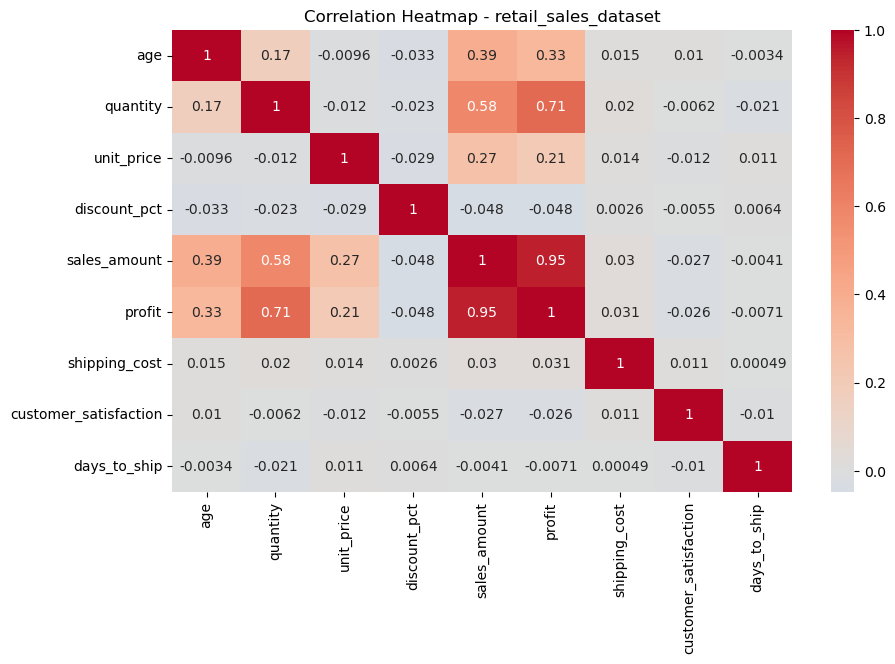

In [24]:

# Eliminar filas con NaN para analisis de correlacion
df_corr = df[num_cols].dropna()

# Calcular correlación
corr = df_corr.corr()

#Heatmap de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - retail_sales_dataset")
plt.show()

#### Consideraciones
**Problema identificado:**
- Existen valores NaN en la columna `quantity`
- Impiden análisis completo de volúmenes de venta

**Decisión:** ELIMINAR registros

**Justificación:**
- Se comprobó por medio de formulas y correlaciones que no se cuenta con información necesaria para hacer algún calculo inverso con los datos de 'profit', 'sales_amount' u otra columna relacionada con ventas.
- El porcentaje de registros con valores nulos en 'quantity' representa solo el 2.59% por lo que omitir estos registros no afectará el análisis

In [25]:
#Eliminar registros con valores nulos en quantity
df = df.dropna(subset=["quantity"])


In [26]:

#Verificar valores nulos
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100)
})
nulos

,nulos,porcentaje_nulos
order_id,0,0.000000
order_date,0,0.000000
customer_id,0,0.000000
customer_name,0,0.000000
age,121,2.956989
gender,0,0.000000
region,0,0.000000
city,0,0.000000
product_category,0,0.000000
product_name,0,0.000000


In [27]:
#Analizar outliers en la columna "age" para poder realizar imputaciones con mediana
df["age"].unique()

array([ 39.,  28.,  41.,  29.,   9.,  31.,  43.,  44.,  17.,  51.,  14.,
        15.,  53.,  30.,  26.,  21.,  35.,  22.,  20.,  65.,  27.,  52.,
        42.,  40.,  -6.,  49., 999.,  34.,  38.,  57.,  36.,  48.,  37.,
        nan,  32.,  33.,  45.,  23.,  16.,  10.,  25.,  24.,  11.,  12.,
        50.,  54.,  46.,  56.,  47.,  19.,  18.,  58.,  -5.,  66.,   8.,
        61.,  55.,   5.,   2.,  60.,  63.,  13.,  59.,   0.,   6.,  -1.,
        -2.,   7., 150.,  62.,  69.,   4.,  68.,   3.,  71.,  -4.,  64.,
         1.,  67.,  72.,  -7.])

In [28]:
# Valores menor o igual a 0
negativos = df[df["age"] <= 0]
print(f"\nEdades negativas: {len(negativos)}")
print(negativos["age"].value_counts())



Edades negativas: 17
age
 0.0    5
-5.0    4
-2.0    2
-7.0    2
-4.0    2
-6.0    1
-1.0    1
Name: count, dtype: int64


In [29]:

# Valores extremos
extremos = df[df["age"] > 100]
print(f"\nEdades > 100: {len(extremos)}")
print(extremos["age"].value_counts())


Edades > 100: 8
age
999.0    5
150.0    3
Name: count, dtype: int64


#### Consideraciones
- Eliminar registros con edades imposibles

In [30]:
#Eliminar registros con edades negativas o mayores a 100
df = df[(df["age"] > 0) & (df["age"] <= 100)]
df = df.reset_index(drop=True)

print(df["age"].unique())

[39. 28. 41. 29.  9. 31. 43. 44. 17. 51. 14. 15. 53. 30. 26. 21. 35. 22.
 20. 65. 27. 52. 42. 40. 49. 34. 38. 57. 36. 48. 37. 32. 33. 45. 23. 16.
 10. 25. 24. 11. 12. 50. 54. 46. 56. 47. 19. 18. 58. 66.  8. 61. 55.  5.
  2. 60. 63. 13. 59.  6.  7. 62. 69.  4. 68.  3. 71. 64.  1. 67. 72.]


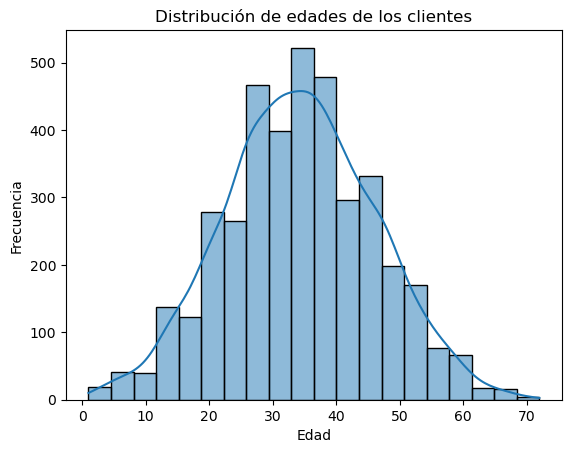

In [31]:
#Observar la distribución de la columna "age" mediante un histograma
sns.histplot(data=df, x="age", bins=20, kde=True)
plt.title("Distribución de edades de los clientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

In [32]:
#Encontrar cantidad de registros con edades menores a 18 años
menores_18=df[df["age"] < 18].shape[0] 
print(f"Cantidad de registros con edades menores a 18 años: {menores_18}")

Cantidad de registros con edades menores a 18 años: 307


#### Consideraciones
**Problema identificado:**
* 307 registros con age < 18 años
* Incluye valores como 1, 2, 3... años

**Decisión: CONSERVAR estos registros**

Justificación / Supuestos:
1. Contexto de negocio: Dataset de ventas retail
2. Interpretación alternativa de 'age':
    * NO es necesariamente la edad del cliente
    * El cliente real que compró es probablemente adulto.

3. Evidencia de validez:
    * Valores entre 1-17 años tienen frecuencias similares a otras edades
    * No son valores extremos aleatorios (como 999 o negativos)
    * Forman un patrón lógico en la distribución

In [33]:
#Imputar valores nulos en la columna "age" con la mediana de la columna
mediana_age = df["age"].median()
df["age"].fillna(mediana_age)

0       39.0
1       28.0
2       41.0
3       29.0
4        9.0
        ... 
3941    45.0
3942    25.0
3943    39.0
3944    40.0
3945    23.0
Name: age, Length: 3946, dtype: float64

In [34]:
#Verificar valores nulos
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100)
})
nulos

,nulos,porcentaje_nulos
order_id,0,0.000000
order_date,0,0.000000
customer_id,0,0.000000
customer_name,0,0.000000
age,0,0.000000
gender,0,0.000000
region,0,0.000000
city,0,0.000000
product_category,0,0.000000
product_name,0,0.000000


#### Consideraciones
- Se ha realizado el tratamiento de nulos para las columnas de interés
- El dataset se encuentra listo para continuar analizando Outliers en el resto de columnas y concluir con la limpieza

In [35]:
#Revisar estadisticas descriptivas de las columnas numéricas después de la limpieza de datos
df[num_cols].describe()

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,3946.000000,3946.000000,3946.000000,3817.000000,3.946000e+03,3.946000e+03,3946.000000,3623.000000,3857.000000
mean,34.269387,7.247592,10696.898406,0.202782,6.028688e+04,1.153230e+04,63.456581,3.024841,5.644024
std,11.862335,41.915308,17411.550783,0.118005,1.790503e+05,3.886546e+04,18.409755,1.413019,4.266178
min,1.000000,-1.000000,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,1.000000,-1.000000
25%,26.000000,3.000000,682.365000,0.100000,2.544595e+03,7.457625e+02,50.777500,2.000000,3.000000
50%,34.000000,5.000000,2233.945000,0.210000,9.947960e+03,3.303600e+03,63.510000,3.000000,6.000000
75%,42.000000,8.000000,12838.712500,0.310000,5.318607e+04,1.099496e+04,75.835000,4.000000,8.000000
max,72.000000,999.000000,79957.920000,0.400000,7.936261e+06,1.739854e+06,133.350000,5.000000,100.000000


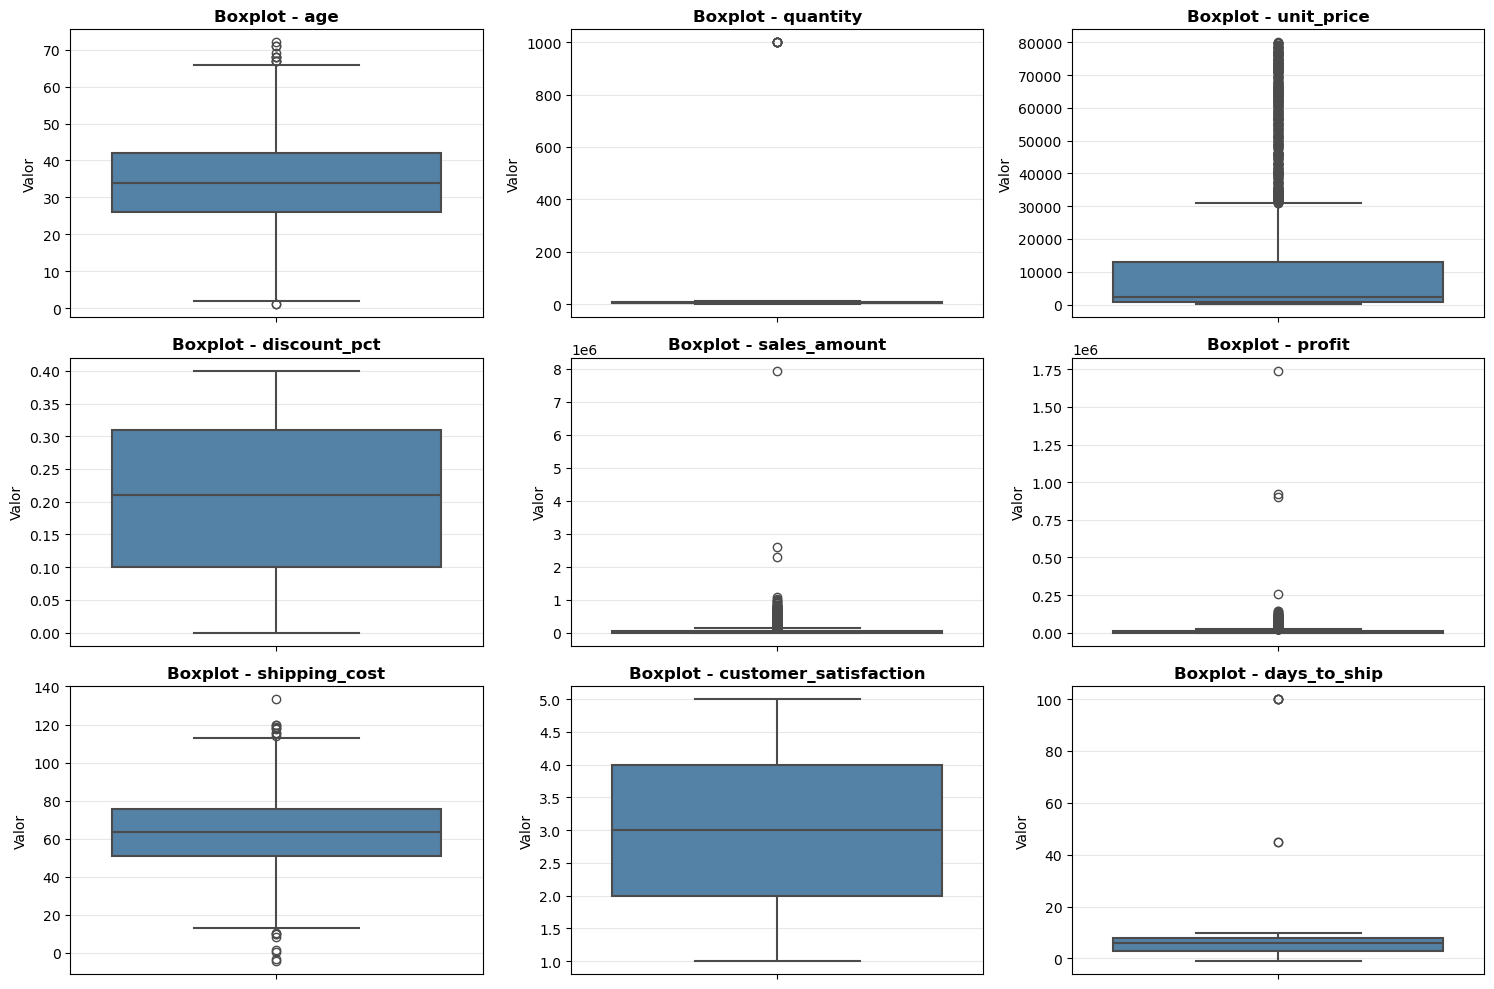

In [36]:
#Crear función para generar boxplots en grilla
def crear_boxplots_grid(df, num_cols, filas=3, columnas=3, figsize=(15, 10)):
 
    # axes = array 2D con los 9 subplots (3 filas × 3 columnas)
    fig, axes = plt.subplots(filas, columnas, figsize=figsize)
    
    # Aplanar el array 2D a 1D para acceder más fácil
    axes = axes.flatten()
    
    # CICLO: para cada columna, crear un boxplot
    # idx = número (0, 1, 2, 3...)
    for idx, col in enumerate(num_cols):
        
        # Crear boxplot CON SEABORN 
        # ax=axes[idx] → en qué subplot ponerlo
        sns.boxplot(data=df, y=col, ax=axes[idx], 
                   color="steelblue", linewidth=1.5)
        
        # Poner un título al subplot
        axes[idx].set_title(f"Boxplot - {col}", fontweight="bold")
        
        # Etiquetar el eje Y (vertical)
        axes[idx].set_ylabel("Valor")
        
        # Agregar líneas de referencia (grilla) en el eje Y
        axes[idx].grid(axis="y", alpha=0.3)
    
    # SEGUNDO CICLO: Ocultar los subplots que no se usan
    # range(len(num_cols), len(axes)) = rango de índices vacíos
    for idx in range(len(num_cols), len(axes)):
        
        # Hacer invisible ese subplot específico
        # False = no mostrarlo
        axes[idx].set_visible(False)
    
    # Ajustar automáticamente los espacios entre subplots
    plt.tight_layout()
    plt.show()

# 1. Usar función
crear_boxplots_grid(df, num_cols)



#### Observaciones
* Existen registros en la columna quantity que distorsionan la distribución de las demas columnas. 
**Desición:** Eliminar registros para evitar sesgos.

In [37]:
#Verificar outliers de quantity
df["quantity"].value_counts().sort_index()

quantity
-1.0        6
 0.0       12
 1.0      393
 2.0      409
 3.0      397
 4.0      401
 5.0      362
 6.0      350
 7.0      381
 8.0      418
 9.0      415
 10.0     395
 999.0      7
Name: count, dtype: int64

#### Consideraciones
**Problema:** Existen 7 registros extremadamente fuera de rango y registros con valor negativo.

**Supuesto:** Los valores por encima de 10 pueden deberse a error en la caprtura de datos o valores sentinels sin explicación/ Los valores negativos pueden referirse a algún articulo del cual se realizó una devolución.

**Desición:** Elimiar registros.

**Justificación:** Los registros extremadamente altos no representan, en cantidad, un volumen suficiente (>5%) para afectar el anañisis, en cuanto a los valroes negativos puede deberse a un caso aislado.

In [38]:
#Eliminar registros con valores de quantity mayores a 10 y negativos
df = df[(df["quantity"] <= 10) & (df["quantity"] >0) ]
df = df.reset_index(drop=True)

#Revisar valores en quantity 
df["quantity"].value_counts().sort_index()

quantity
1.0     393
2.0     409
3.0     397
4.0     401
5.0     362
6.0     350
7.0     381
8.0     418
9.0     415
10.0    395
Name: count, dtype: int64

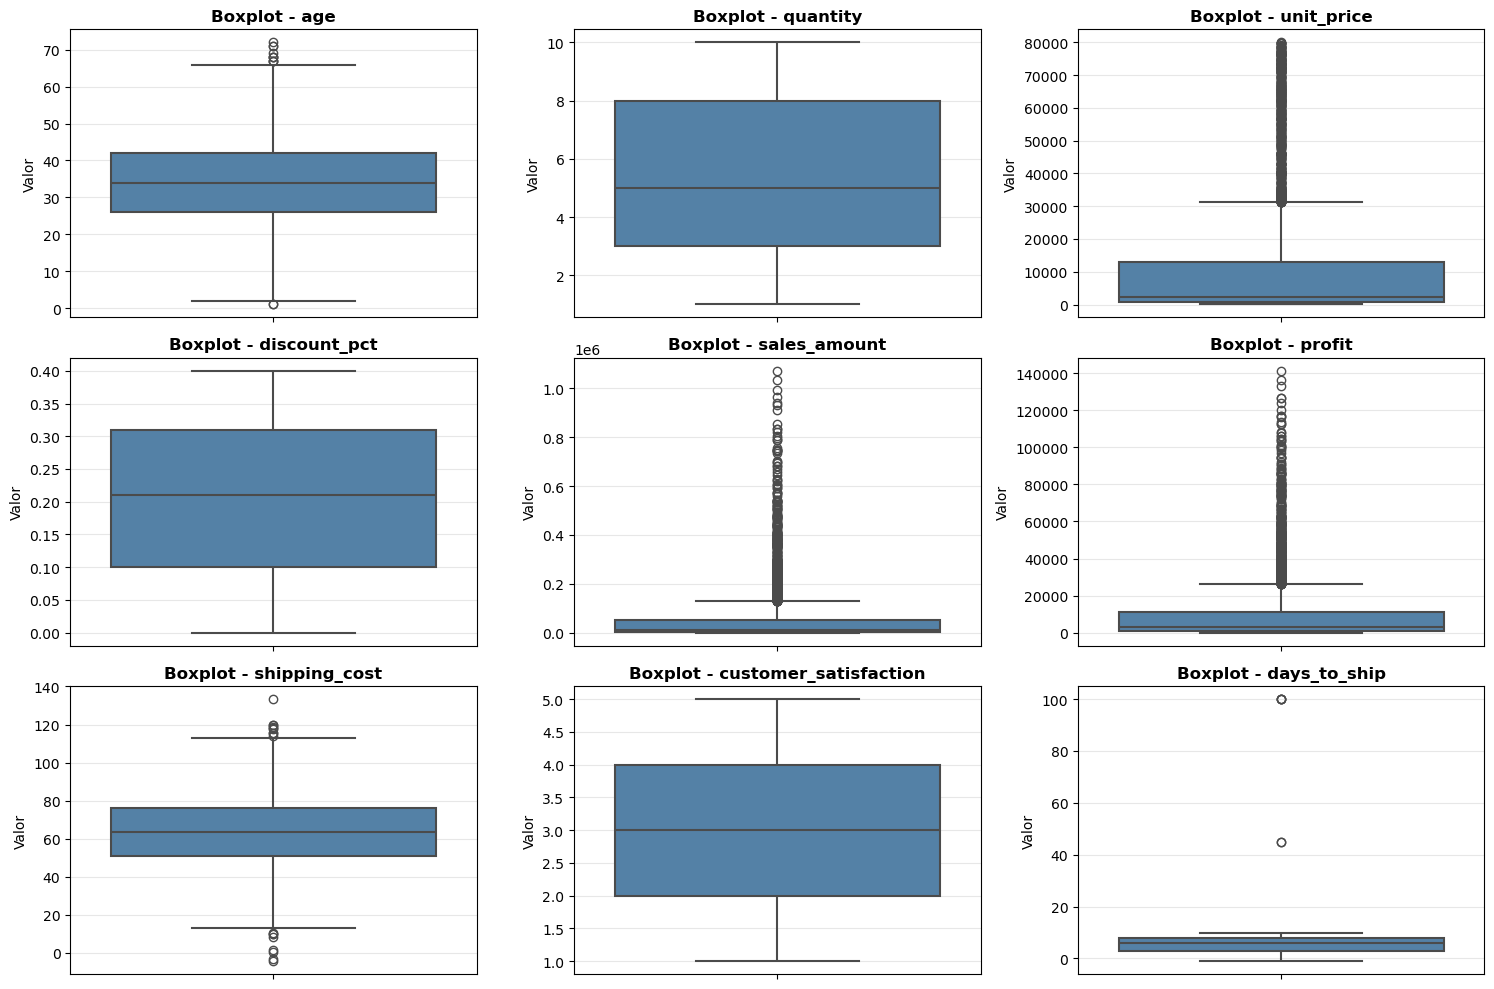

In [39]:
# Verificar nuevamente la distribución de las columnas numéricas mediante boxplots 
crear_boxplots_grid(df, num_cols)



In [40]:
#Revisar rango de fechas de la columna "order_date"
df["order_date"].describe()

count                             3921
mean     2022-07-03 16:27:32.639632640
min                2020-01-01 00:00:00
25%                2021-04-21 00:00:00
50%                2022-07-08 00:00:00
75%                2023-09-16 00:00:00
max                2024-12-30 00:00:00
Name: order_date, dtype: object

#### Observaciones
* El rango de fechas es congruente para el análisis, rango 01-01-2020 al 30-12-2024


#### Consideraciones

**Tratamiento de Outliers - Decisiones Finales**

**1. Variables Numéricas Incluidas en Análisis RFM**

   **age, quantity, unit_price, discount_pct, sales_amount, profit, customer_satisfaction**
   - Relevantes para segmentación de clientes
   - Outliers mantenidos (reflejan comportamiento real)

**2. Variables Excluidas del Análisis Actual**

   **shipping_cost, days_to_ship**
   - Relevancia: Operacional/Logística (NO para RFM)
   - Outliers detectados: Potenciales ineficiencias
   - Decisión: IGNORAR para este análisis
   - Recomendación: Derivar a equipo de Operaciones

---

**Recomendaciones para Equipo de Operaciones**

- Los outliers en shipping_cost y days_to_ship merecen investigación:

**Proximos pasos**
**1. Análisis de Comportamiento de Ventas y Segmentacion**

**Objetivo:** Entender dinámicas generales de ventas

**Análisis a realizar:**
- Tendencia temporal de ventas (mes a mes, trimestral)
- Top 5 productos más vendidos vs más rentables
- Relación cantidad vendida vs margen de ganancia


**2. Segmentación por Edad (Cohortes de Edad)**

**Objetivo:** Identificar patrones de compra por grupo demográfico

**Segmentación propuesta:**
- Menores de 18 años (Clientes de productos infantiles)
- 18-30 años (Millennials/Jóvenes profesionales)
- 31-45 años (Profesionales establecidos)
- 46-60 años (Pre-jubilados)
- Mayor de 60 años (Jubilados)

**Análisis por cohorte:**
- AOV (Average Order Value) por edad
- Frecuencia de compra
- Categorías preferidas
- Sensibilidad al descuento
- Satisfacción del cliente

**Pregunta:** ¿Qué grupo de edad es más rentable y por qué?

---

**3. Segmentación por Categoría de Producto**

**Objetivo:** Desglosar dinámicas de sales_amount por tipo de producto

**Análisis a realizar:**
- Sales_amount promedio por categoría
- Margen de ganancia por categoría
- Volumen (quantity) por categoría
- Descuentos aplicados por categoría
- Satisfacción del cliente por categoría

**Pregunta clave:** ¿Hay categorías que generan volumen pero bajo margen?

---

**4. Análisis Geográfico (Por Región/Ciudad)**

**Objetivo:** Identificar variaciones regionales en comportamiento de compra

**Análisis a realizar:**
- Sales_amount total y promedio por región
- Productos más vendidos por región
- Sensibilidad al descuento por región
- Tiempos de envío por región
- Satisfacción del cliente por región

**Pregunta:** ¿Hay regiones subexplotadas con potencial de crecimiento?

---

**5. Análisis de Estacionalidad**

**Objetivo:** Detectar patrones temporales en las ventas

**Análisis a realizar:**
- Ventas por mes del año
- Ventas por trimestre
- Ventas por día de la semana (si aplica)
- Picos y valles de demanda
- Productos estacionales

**Pregunta:** ¿Hay períodos donde ciertas categorías o regiones disparan?



In [49]:
print("=" * 70)
print("EXPORTACIÓN: Guardando dataset limpio")
print("=" * 70)

# Verificación final
print(f"\n ESTADÍSTICAS FINALES:")
print(f"  • Registros: {len(df)}")
print(f"  • Columnas: {df.shape[1]}")
print(f"  • Valores nulos: {df.isnull().sum().sum()}")
print(f"  • Tipos de datos: {df.dtypes.unique()}")
print(f"\nRegistros originales: {len(df_raw)}")
print(f"Registros eliminados: {len(df_raw) - len(df)}")
print(f"Porcentaje de registros eliminados: {((len(df_raw) - len(df)) / len(df_raw)) * 100:.2f}%")

# Guardar como CSV
csv_path = '../data/clean/retail_sales_clean.csv'

df.to_csv(csv_path, index=False, encoding='utf-8')

print(f"CSV guardado: {csv_path}")


# Verificación de lectura
df_test = pd.read_csv(csv_path)
print(f" Verificación: {len(df_test)} registros cargados correctamente")

print("\n" + "=" * 70)
print("NOTEBOOK DE LIMPIEZA COMPLETADO")
print("=" * 70)

EXPORTACIÓN: Guardando dataset limpio

 ESTADÍSTICAS FINALES:
  • Registros: 3921
  • Columnas: 21
  • Valores nulos: 538
  • Tipos de datos: [dtype('O') dtype('<M8[ns]') dtype('float64') dtype('bool')]

Registros originales: 4310
Registros eliminados: 389
Porcentaje de registros eliminados: 9.03%
CSV guardado: ../data/clean/retail_sales_clean.csv
 Verificación: 3921 registros cargados correctamente

NOTEBOOK DE LIMPIEZA COMPLETADO
